# Teoria da Decisão - ENTREGA #2: Otimização Multi-objetivo

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import time

## 1. Carregamento de Dados

In [12]:
try:
    distancia_df = pd.read_csv('distancia.csv', header=None)
    distancia_matrix = distancia_df.values

    tempo_df = pd.read_csv('tempo.csv', header=None)
    tempo_matrix = tempo_df.values

    print(f"Matriz de distâncias carregada com sucesso. Shape: {distancia_matrix.shape}")
    print(f"Matriz de tempos carregada com sucesso. Shape: {tempo_matrix.shape}")
except FileNotFoundError as e:
    print(f"Erro: Arquivo não encontrado. Verifique se os arquivos .csv estão no diretório correto. {e}")

Matriz de distâncias carregada com sucesso. Shape: (250, 250)
Matriz de tempos carregada com sucesso. Shape: (250, 250)


## Funções Base do Algoritmo GVNS

In [13]:
def calcular_custo(rota, matriz_custo):
    custo_total = 0
    for i in range(len(rota) - 1):
        custo_total += matriz_custo[rota[i], rota[i+1]]
    custo_total += matriz_custo[rota[-1], rota[0]]
    return custo_total

def heuristica_construtiva_gulosa_aleatorizada(matriz_custo, rcl_size=3):
    num_cidades = matriz_custo.shape[0]
    cidade_inicial = np.random.randint(num_cidades)
    rota = [cidade_inicial]
    cidades_nao_visitadas = list(range(num_cidades))
    cidades_nao_visitadas.remove(cidade_inicial)
    cidade_atual = cidade_inicial
    while cidades_nao_visitadas:
        custos = [(matriz_custo[cidade_atual, proxima_cidade], proxima_cidade) for proxima_cidade in cidades_nao_visitadas]
        custos.sort()
        rcl = custos[:rcl_size]
        _, proxima_cidade = rcl[np.random.randint(len(rcl))]
        rota.append(proxima_cidade)
        cidades_nao_visitadas.remove(proxima_cidade)
        cidade_atual = proxima_cidade
    return np.array(rota)

def vizinhanca_2_opt(rota):
    num_cidades = len(rota)
    i, j = np.random.choice(num_cidades, 2, replace=False)
    if i > j: i, j = j, i
    nova_rota = np.copy(rota)
    nova_rota[i:j+1] = np.flip(nova_rota[i:j+1])
    return nova_rota

def vizinhanca_or_opt(rota, tamanho_bloco=3):
    num_cidades = len(rota)
    i = np.random.randint(0, num_cidades - tamanho_bloco)
    j = np.random.randint(0, num_cidades - tamanho_bloco)
    bloco = rota[i:i+tamanho_bloco]
    rota_sem_bloco = np.delete(rota, np.arange(i, i + tamanho_bloco))
    return np.insert(rota_sem_bloco, j, bloco)

def vizinhanca_double_bridge(rota):
    num_cidades = len(rota)
    indices = sorted(np.random.choice(num_cidades, 4, replace=False))
    i, j, k, l = indices
    parte1 = rota[:i]
    parte2 = rota[i:j]
    parte3 = rota[j:k]
    parte4 = rota[k:l]
    parte5 = rota[l:]
    return np.concatenate([parte1, parte4, parte3, parte2, parte5])

def vnd(rota_inicial, obj_func, vizinhancas):
    melhor_rota = np.copy(rota_inicial)
    melhor_custo = obj_func(melhor_rota)
    l = 0
    while l < len(vizinhancas):
        vizinhanca = vizinhancas[l]
        nova_rota = vizinhanca(melhor_rota)
        novo_custo = obj_func(nova_rota)
        if novo_custo < melhor_custo:
            melhor_rota = nova_rota
            melhor_custo = novo_custo
            l = 0
        else:
            l += 1
    return melhor_rota, melhor_custo

def gvns(obj_func, matriz_custo_heuristica, vizinhancas, kmax, max_iter_sem_melhora, return_curve=False):
    rota_inicial = heuristica_construtiva_gulosa_aleatorizada(matriz_custo_heuristica)
    melhor_rota, melhor_custo = vnd(rota_inicial, obj_func, vizinhancas)
    historico_custos = [melhor_custo]
    iter_sem_melhora = 0
    while iter_sem_melhora < max_iter_sem_melhora:
        k = 0
        while k < kmax:
            vizinhanca_shake = vizinhancas[k]
            rota_perturbada = vizinhanca_shake(melhor_rota)
            nova_rota, novo_custo = vnd(rota_perturbada, obj_func, vizinhancas)
            if novo_custo < melhor_custo:
                melhor_rota = nova_rota
                melhor_custo = novo_custo
                k = 0
                iter_sem_melhora = 0
            else:
                k += 1
                iter_sem_melhora += 1
            historico_custos.append(melhor_custo)
    if return_curve:
        return melhor_rota, melhor_custo, historico_custos
    else:
        return melhor_rota, melhor_custo

## 2. Normalização e Definição dos Extremos

In [14]:
min_tempo = 33.8
max_tempo = 38.6
min_distancia = 1384.5
max_distancia = 1555.0

def normalizar(valor, min_val, max_val):
    # Evita divisão por zero se min e max forem iguais
    if max_val - min_val == 0:
        return 0.0
    return (valor - min_val) / (max_val - min_val)

In [15]:
# Normalização das matrizes de custo para a heurística
# Para evitar que a escala de uma matriz domine a outra na heurística ponderada
min_dist_val = np.min(distancia_matrix[np.nonzero(distancia_matrix)])
max_dist_val = np.max(distancia_matrix)
min_tempo_val = np.min(tempo_matrix[np.nonzero(tempo_matrix)])
max_tempo_val = np.max(tempo_matrix)

distancia_matrix_norm = (distancia_matrix - min_dist_val) / (max_dist_val - min_dist_val)
tempo_matrix_norm = (tempo_matrix - min_tempo_val) / (max_tempo_val - min_tempo_val)

### Modelagem Matemática: Soma Ponderada (Pw)

A abordagem da Soma Ponderada transforma o problema multiobjetivo em um problema mono-objetivo, minimizando uma combinação linear das funções objetivo. A função objetivo agregada F(x) é definida como:

$$ \min F(x) = w \cdot f_{\text{tempo,norm}}(x) + (1-w) \cdot f_{\text{dist,norm}}(x) $$

Onde:
- `x` é uma rota válida.
- `w` é um peso, com `0 <= w <= 1`.
- `f_norm(x)` é a função objetivo normalizada, calculada como: `(f(x) - f_min) / (f_max - f_min)`. A normalização é crucial para que as funções objetivo, que possuem escalas diferentes, contribuam de forma equilibrada para a função agregada.

## 3. Implementação da Soma Ponderada (Pw)

In [ ]:
def make_objf_Pw(w):
    def objf_Pw(rota):
        custo_tempo = calcular_custo(rota, tempo_matrix)
        custo_distancia = calcular_custo(rota, distancia_matrix)
        norm_tempo = normalizar(custo_tempo, min_tempo, max_tempo)
        norm_distancia = normalizar(custo_distancia, min_distancia, max_distancia)
        return w * norm_tempo + (1 - w) * norm_distancia
    return objf_Pw

def run_gvns_wrapper_Pw(w):
    try:
        obj_func = make_objf_Pw(w)
        # Usa uma matriz de custo combinada para a heurística
        matriz_custo_heuristica = w * tempo_matrix_norm + (1 - w) * distancia_matrix_norm
        rota_final, _ = gvns(obj_func, matriz_custo_heuristica, [vizinhanca_2_opt, vizinhanca_or_opt, vizinhanca_double_bridge], 3, 1000)
        custo_tempo_final = calcular_custo(rota_final, tempo_matrix)
        custo_distancia_final = calcular_custo(rota_final, distancia_matrix)
        return (custo_tempo_final, custo_distancia_final)
    except Exception as e:
        print(f"[ERRO] Wrapper Soma Ponderada falhou: {e}")
        return None

def executar_uma_repeticao_Pw(num_pesos):
    pesos = [random.uniform(0, 1) for _ in range(num_pesos)]
    resultados = list(map(run_gvns_wrapper_Pw, pesos))
    return resultados

### Modelagem Matemática: Epsilon-Restrito (Pe)

A abordagem Epsilon-Restrito otimiza uma das funções objetivo (`f_dist(x)`) enquanto trata a outra (`f_tempo(x)`) como uma restrição, que não deve exceder um valor `epsilon`. O problema é formulado como:

$$ \min f_{\text{dist}}(x) $$

Sujeito a:
$$ f_{\text{tempo}}(x) \le \epsilon $$

Para resolver com uma metaheurística, transformamos o problema restrito em um não restrito usando uma função de penalidade. A nova função objetivo a ser minimizada é:

$$ \min F(x) = f_{\text{dist}}(x) + P \cdot \max(0, f_{\text{tempo}}(x) - \epsilon) $$

Onde `P` é um fator de penalidade grande o suficiente para garantir que a restrição seja atendida.

## 4. Implementação do Epsilon-Restrito (Pe)

In [ ]:
def make_objf_Pe(epsilon, penalidade=1000):
    def objf_Pe(rota):
        custo_tempo = calcular_custo(rota, tempo_matrix)
        custo_distancia = calcular_custo(rota, distancia_matrix)
        penalidade_aplicada = penalidade * max(0, custo_tempo - epsilon)
        return custo_distancia + penalidade_aplicada
    return objf_Pe

def run_gvns_wrapper_Pe(epsilon):
    try:
        obj_func = make_objf_Pe(epsilon)
        rota_final, _ = gvns(obj_func, distancia_matrix, [vizinhanca_2_opt, vizinhanca_or_opt, vizinhanca_double_bridge], 3, 1000)
        custo_tempo_final = calcular_custo(rota_final, tempo_matrix)
        custo_distancia_final = calcular_custo(rota_final, distancia_matrix)
        return (custo_tempo_final, custo_distancia_final)
    except Exception as e:
        print(f"[ERRO] Wrapper Epsilon-Restrito falhou: {e}")
        return None

def executar_uma_repeticao_Pe(num_epsilons):
    epsilons = [random.uniform(min_tempo, max_tempo) for _ in range(num_epsilons)]
    resultados = list(map(run_gvns_wrapper_Pe, epsilons))
    return resultados

## 5. Execução e Plotagem das Fronteiras de Pareto

--- Repetição 1/5 ---
Executando Soma Ponderada...
Executando Epsilon-Restrito...
--- Repetição 2/5 ---
Executando Soma Ponderada...
Executando Epsilon-Restrito...
--- Repetição 3/5 ---
Executando Soma Ponderada...
Executando Epsilon-Restrito...
--- Repetição 4/5 ---
Executando Soma Ponderada...
Executando Epsilon-Restrito...
--- Repetição 5/5 ---
Executando Soma Ponderada...
Executando Epsilon-Restrito...


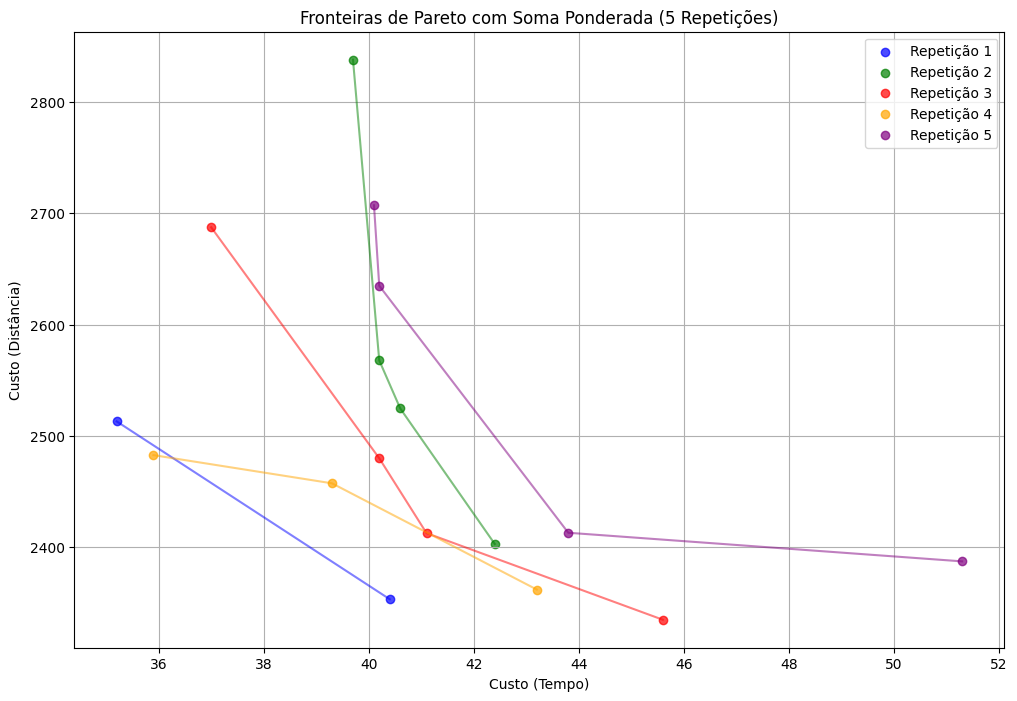

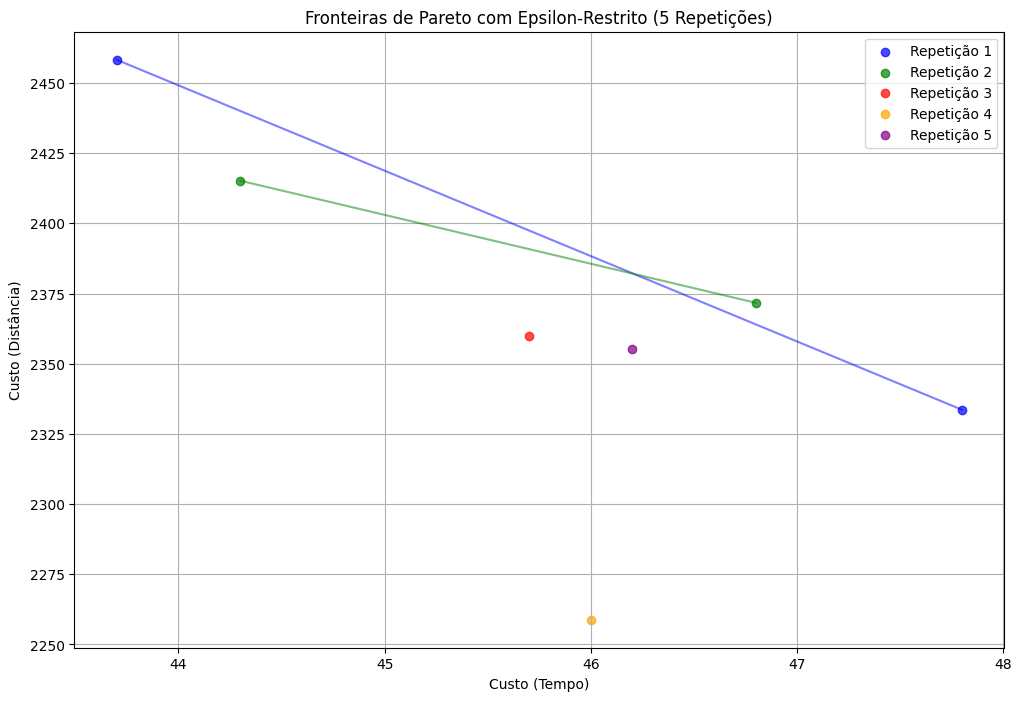

In [18]:
NUM_REPETICOES = 5
NUM_PONTOS_FRONTEIRA = 20

# Armazena os pontos brutos de todas as repetições para o cálculo da fronteira global
todos_os_pontos_Pw_raw = []
todos_os_pontos_Pe_raw = []

# Armazena as fronteiras de cada repetição para a plotagem
frentes_por_repeticao_Pw = []
frentes_por_repeticao_Pe = []

def encontrar_fronteira_pareto(pontos):
    """Encontra o conjunto de soluções não-dominadas (Fronteira de Pareto) de um conjunto de pontos."""
    # Remove pontos duplicados
    pontos_unicos = np.unique(np.array(pontos), axis=0)
    if len(pontos_unicos) == 0:
        return np.array([])
    fronteira_indices = []
    for i, p1 in enumerate(pontos_unicos):
        dominado = False
        for j, p2 in enumerate(pontos_unicos):
            if i == j:
                continue
            # p2 domina p1 se for melhor ou igual em todos os objetivos e estritamente melhor em pelo menos um.
            if np.all(p2 <= p1) and np.any(p2 < p1):
                dominado = True
                break
        if not dominado:
            fronteira_indices.append(i)
    return pontos_unicos[fronteira_indices]

for i in range(NUM_REPETICOES):
    print(f"--- Repetição {i+1}/{NUM_REPETICOES} ---")
    
    print("Executando Soma Ponderada...")
    fronteira_pw_raw = executar_uma_repeticao_Pw(NUM_PONTOS_FRONTEIRA)
    fronteira_pw = [p for p in fronteira_pw_raw if p is not None]
    if fronteira_pw:
        todos_os_pontos_Pw_raw.extend(fronteira_pw)
        frente_pw_repeticao = encontrar_fronteira_pareto(fronteira_pw)
        frentes_por_repeticao_Pw.append(frente_pw_repeticao)

    print("Executando Epsilon-Restrito...")
    fronteira_pe_raw = executar_uma_repeticao_Pe(NUM_PONTOS_FRONTEIRA)
    fronteira_pe = [p for p in fronteira_pe_raw if p is not None]
    if fronteira_pe:
        todos_os_pontos_Pe_raw.extend(fronteira_pe)
        frente_pe_repeticao = encontrar_fronteira_pareto(fronteira_pe)
        frentes_por_repeticao_Pe.append(frente_pe_repeticao)

# Plotando as 5 fronteiras de Pareto (Pw)
plt.figure(figsize=(12, 8))
cores = ['blue', 'green', 'red', 'orange', 'purple']
for i, fronteira in enumerate(frentes_por_repeticao_Pw):
    if fronteira.size > 0:
        fronteira = fronteira[fronteira[:, 0].argsort()]
        plt.scatter(fronteira[:, 0], fronteira[:, 1], label=f"Repetição {i+1}", alpha=0.7, color=cores[i % len(cores)])
        plt.plot(fronteira[:, 0], fronteira[:, 1], alpha=0.5, color=cores[i % len(cores)])

plt.title("Fronteiras de Pareto com Soma Ponderada (5 Repetições)")
plt.xlabel("Custo (Tempo)")
plt.ylabel("Custo (Distância)")
plt.grid(True)
plt.legend()
plt.show()

# Plotando as 5 fronteiras de Pareto (Pe)
plt.figure(figsize=(12, 8))
for i, fronteira in enumerate(frentes_por_repeticao_Pe):
    if fronteira.size > 0:
        fronteira = fronteira[fronteira[:, 0].argsort()]
        plt.scatter(fronteira[:, 0], fronteira[:, 1], label=f"Repetição {i+1}", alpha=0.7, color=cores[i % len(cores)])
        plt.plot(fronteira[:, 0], fronteira[:, 1], alpha=0.5, color=cores[i % len(cores)])

plt.title("Fronteiras de Pareto com Epsilon-Restrito (5 Repetições)")
plt.xlabel("Custo (Tempo)")
plt.ylabel("Custo (Distância)")
plt.grid(True)
plt.legend()
plt.show()

## 6. Filtragem e Salvamento dos Resultados

In [19]:
def filtrar_fronteira_por_distancia(fronteira, num_pontos=20):
    """Filtra a fronteira para um número específico de pontos, garantindo uma boa distribuição.
    A seleção é feita de forma iterativa, escolhendo-se sempre o ponto mais distante dos já selecionados."""
    if len(fronteira) <= num_pontos:
        return fronteira

    # Normalizar os pontos para o cálculo da distância euclidiana não ser enviesado pela escala.
    min_vals = fronteira.min(axis=0)
    max_vals = fronteira.max(axis=0)
    delta = max_vals - min_vals
    delta[delta == 0] = 1.0
    fronteira_norm = (fronteira - min_vals) / delta

    pontos_selecionados_indices = [np.argmin(np.sum(fronteira_norm, axis=1))]

    while len(pontos_selecionados_indices) < num_pontos and len(pontos_selecionados_indices) < len(fronteira):
        distancias_minimas_ao_quadrado = []
        pontos_nao_selecionados_indices = [i for i in range(len(fronteira_norm)) if i not in pontos_selecionados_indices]

        for i in pontos_nao_selecionados_indices:
            dist_ao_quadrado = np.sum((fronteira_norm[i] - fronteira_norm[pontos_selecionados_indices])**2, axis=1)
            distancias_minimas_ao_quadrado.append(np.min(dist_ao_quadrado))
        
        proximo_ponto_idx_local = np.argmax(distancias_minimas_ao_quadrado)
        proximo_ponto_idx_global = pontos_nao_selecionados_indices[proximo_ponto_idx_local]
        pontos_selecionados_indices.append(proximo_ponto_idx_global)

    return fronteira[pontos_selecionados_indices]

# --- Início da execução da filtragem ---

Fronteira final (Soma Ponderada) com 5 pontos salva em 'fronteira_final_Pw.csv'
Fronteira final (Epsilon-Restrito) com 4 pontos salva em 'fronteira_final_Pe.csv'


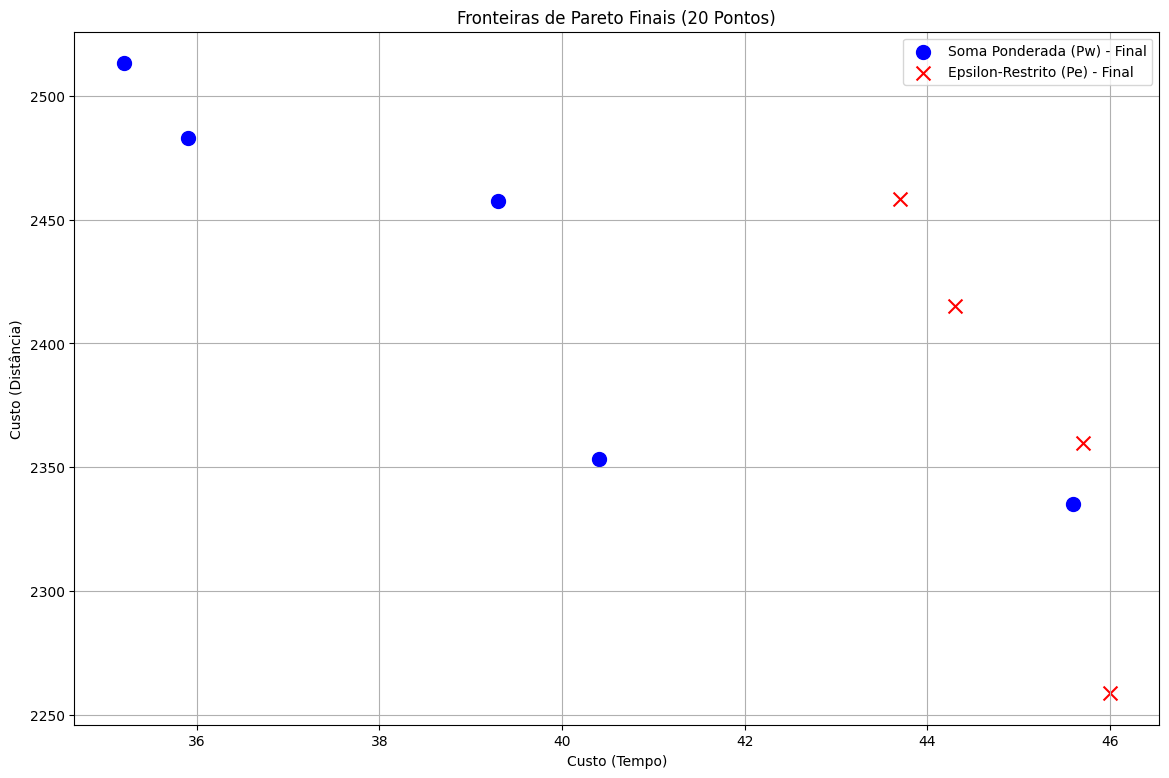

In [20]:
if not todos_os_pontos_Pw_raw and not todos_os_pontos_Pe_raw:
    print("AVISO: Nenhuma solução foi encontrada em nenhuma das abordagens. A filtragem final não será executada.")
else:
    # Encontrar a fronteira de Pareto global para cada método a partir de todos os pontos
    if todos_os_pontos_Pw_raw:
        fronteira_global_Pw = encontrar_fronteira_pareto(np.array(todos_os_pontos_Pw_raw))
        fronteira_filtrada_Pw = filtrar_fronteira_por_distancia(fronteira_global_Pw, 20)
        pd.DataFrame(fronteira_filtrada_Pw, columns=['Tempo', 'Distancia']).to_csv('fronteira_final_Pw.csv', index=False)
        print(f"Fronteira final (Soma Ponderada) com {len(fronteira_filtrada_Pw)} pontos salva em 'fronteira_final_Pw.csv'")
    else:
        fronteira_filtrada_Pw = np.array([])
        print("Nenhuma solução encontrada para a Soma Ponderada.")

    if todos_os_pontos_Pe_raw:
        fronteira_global_Pe = encontrar_fronteira_pareto(np.array(todos_os_pontos_Pe_raw))
        fronteira_filtrada_Pe = filtrar_fronteira_por_distancia(fronteira_global_Pe, 20)
        pd.DataFrame(fronteira_filtrada_Pe, columns=['Tempo', 'Distancia']).to_csv('fronteira_final_Pe.csv', index=False)
        print(f"Fronteira final (Epsilon-Restrito) com {len(fronteira_filtrada_Pe)} pontos salva em 'fronteira_final_Pe.csv'")
    else:
        fronteira_filtrada_Pe = np.array([])
        print("Nenhuma solução encontrada para o Epsilon-Restrito.")

    # Plotar as fronteiras finais para comparação
    plt.figure(figsize=(14, 9))
    if fronteira_filtrada_Pw.size > 0:
        plt.scatter(fronteira_filtrada_Pw[:, 0], fronteira_filtrada_Pw[:, 1], label='Soma Ponderada (Pw) - Final', color='blue', s=100, marker='o')
    if fronteira_filtrada_Pe.size > 0:
        plt.scatter(fronteira_filtrada_Pe[:, 0], fronteira_filtrada_Pe[:, 1], label='Epsilon-Restrito (Pe) - Final', color='red', s=100, marker='x')
    
    plt.title('Fronteiras de Pareto Finais (20 Pontos)')
    plt.xlabel('Custo (Tempo)')
    plt.ylabel('Custo (Distância)')
    plt.legend()
    plt.grid(True)
    plt.show()